In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, average_precision_score,
    brier_score_loss, roc_curve
)

import matplotlib
import matplotlib.pyplot as plt

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT   = Path("/Users/frack/Documents/PhD Data Science/malawi-dhs-2024-geoai")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS         = PROJECT_ROOT / "outputs" / "models"

import lightgbm as lgb
import xgboost as xgb

df        = pd.read_parquet(DATA_PROCESSED / "model_ready_stunting_v2.parquet")
rf        = joblib.load(MODELS / "rf_stunting_v2.pkl")
lgb_model = joblib.load(MODELS / "lgb_stunting_v2.pkl")
xgb_model = joblib.load(MODELS / "xgb_stunting_v2.pkl")

FEATURES = [
    "imm_child_age_months", "enc_age_band", "enc_child_sex",
    "imm_birth_order", "imm_birth_interval", "imm_first_born",
    "imm_short_interval", "imm_high_birth_order",
    "enc_size_at_birth", "enc_had_diarrhea",
    "und_maternal_age", "und_maternal_edu_years", "enc_edu_level",
    "und_maternal_weight_kg", "und_maternal_height_cm",
    "und_maternal_bmi", "und_low_bmi", "und_maternal_stunted",
    "und_total_children", "und_household_size",
    "enc_wealth_index", "enc_residence", "enc_region",
    "enc_district", "enc_religion",
    "district_stunting_rate", "district_mean_age",
    "district_mean_wealth", "district_mean_mat_height"
]

X = df[FEATURES]
y = df["outcome_stunted"]
w = df["sample_weight"]

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing in X:", X.isnull().sum().sum())
print("Sample weight range:", w.min().round(4), "to", w.max().round(4))
print("Zero weights:", (w == 0).sum())
print("\nModels loaded:")
print(" RF:", type(rf).__name__, "| n_features:", rf.n_features_in_)
print(" LGB:", type(lgb_model).__name__)
print(" XGB:", type(xgb_model).__name__)

try:
    from scipy import stats
    import scipy
    print("\nscipy:", scipy.__version__)
except ImportError:
    print("\nscipy not available - run: pip install scipy")

Shape: (5122, 36)
Columns: ['imm_child_age_months', 'enc_age_band', 'enc_child_sex', 'imm_birth_order', 'imm_birth_interval', 'imm_first_born', 'imm_short_interval', 'imm_high_birth_order', 'enc_size_at_birth', 'enc_had_diarrhea', 'und_maternal_age', 'und_maternal_edu_years', 'enc_edu_level', 'und_maternal_weight_kg', 'und_maternal_height_cm', 'und_maternal_bmi', 'und_low_bmi', 'und_maternal_stunted', 'und_total_children', 'und_household_size', 'enc_wealth_index', 'enc_residence', 'enc_region', 'enc_district', 'enc_religion', 'district_stunting_rate', 'district_mean_age', 'district_mean_wealth', 'district_mean_mat_height', 'outcome_stunted', 'sample_weight', 'id_cluster', 'id_household', 'id_child_index', 'str_district', 'str_region']
Missing in X: 0
Sample weight range: 0.0133 to 3.7057
Zero weights: 0

Models loaded:
 RF: RandomForestClassifier | n_features: 29
 LGB: LGBMClassifier
 XGB: XGBClassifier

scipy: 1.15.3


## Cross-validation with confidence intervals

Point estimates alone are insufficient for publication. We compute mean ± standard 
deviation across five folds and derive 95% confidence intervals for each metric. 
The DeLong test formally compares AUC between models on the same test observations.

In [2]:
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_with_ci(model, X, y, w, cv, name):
    fold_metrics = {
        'roc_auc':[], 'pr_auc':[], 'f1':[],
        'recall':[], 'precision':[], 'brier':[]
    }
    all_y_true  = []
    all_y_proba = []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        w_train         = w.iloc[train_idx]

        model.fit(X_train, y_train, sample_weight=w_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        fold_metrics['roc_auc'].append(roc_auc_score(y_test, y_proba))
        fold_metrics['pr_auc'].append(average_precision_score(y_test, y_proba))
        fold_metrics['f1'].append(f1_score(y_test, y_pred))
        fold_metrics['recall'].append(recall_score(y_test, y_pred))
        fold_metrics['precision'].append(precision_score(y_test, y_pred))
        fold_metrics['brier'].append(brier_score_loss(y_test, y_proba))

        all_y_true.extend(y_test.tolist())
        all_y_proba.extend(y_proba.tolist())

    results = {}
    for metric, values in fold_metrics.items():
        mean = np.mean(values)
        sd   = np.std(values, ddof=1)
        se   = sd / np.sqrt(len(values))
        ci_lo = mean - 1.96 * se
        ci_hi = mean + 1.96 * se
        results[metric] = {
            'mean': mean, 'sd': sd,
            'ci_lo': ci_lo, 'ci_hi': ci_hi,
            'values': values
        }

    results['name']       = name
    results['y_true_all'] = all_y_true
    results['y_proba_all']= all_y_proba
    return results

print("Running 5-fold CV with CI computation...")
print("This takes a few minutes.\n")

models_list = [
    (rf,        "Random Forest"),
    (lgb_model, "LightGBM"),
    (xgb_model, "XGBoost"),
]

cv_results = {}
for model, name in models_list:
    print(f"Training {name}...")
    cv_results[name] = cv_with_ci(model, X, y, w, cv, name)

print("\n=== PERFORMANCE WITH 95% CONFIDENCE INTERVALS ===")
print(f"{'Model':<22} {'ROC-AUC':>20} {'F1':>20} {'Recall':>20} {'Brier':>20}")
print("-"*105)
for name, r in cv_results.items():
    roc = f"{r['roc_auc']['mean']:.4f} [{r['roc_auc']['ci_lo']:.4f}-{r['roc_auc']['ci_hi']:.4f}]"
    f1  = f"{r['f1']['mean']:.4f} [{r['f1']['ci_lo']:.4f}-{r['f1']['ci_hi']:.4f}]"
    rec = f"{r['recall']['mean']:.4f} [{r['recall']['ci_lo']:.4f}-{r['recall']['ci_hi']:.4f}]"
    bri = f"{r['brier']['mean']:.4f} [{r['brier']['ci_lo']:.4f}-{r['brier']['ci_hi']:.4f}]"
    print(f"{name:<22} {roc:>20} {f1:>20} {rec:>20} {bri:>20}")

Running 5-fold CV with CI computation...
This takes a few minutes.

Training Random Forest...
Training LightGBM...
Training XGBoost...

=== PERFORMANCE WITH 95% CONFIDENCE INTERVALS ===
Model                               ROC-AUC                   F1               Recall                Brier
---------------------------------------------------------------------------------------------------------
Random Forest          0.6856 [0.6658–0.7054] 0.5101 [0.4951–0.5250] 0.4921 [0.4761–0.5081] 0.2128 [0.2084–0.2173]
LightGBM               0.6692 [0.6533–0.6850] 0.5312 [0.5146–0.5478] 0.5619 [0.5383–0.5855] 0.2270 [0.2211–0.2330]
XGBoost                0.6726 [0.6513–0.6939] 0.5283 [0.5045–0.5522] 0.5543 [0.5309–0.5777] 0.2258 [0.2169–0.2346]


## DeLong test for statistical comparison of AUC

The DeLong test determines whether differences in ROC-AUC between models are 
statistically significant. This is the standard test for comparing two classifiers 
on the same observations. A p-value below 0.05 means the performance difference 
is unlikely to be due to chance.

In [3]:
def delong_test(y_true, y_proba_1, y_proba_2):
    """
    DeLong test for comparing two AUC values on the same test set.
    Returns z-statistic and p-value (two-tailed).
    """
    def compute_midrank(x):
        J = np.argsort(x)
        Z = x[J]
        N = len(x)
        T = np.zeros(N, dtype=float)
        i = 0
        while i < N:
            j = i
            while j < N and Z[j] == Z[i]:
                j += 1
            T[i:j] = 0.5 * (i + j - 1)
            i = j
        T2 = np.empty(N, dtype=float)
        T2[J] = T + 1
        return T2

    def fastDeLong(y_true, y_proba):
        m = np.sum(y_true == 1)
        n = np.sum(y_true == 0)
        pos_proba = y_proba[y_true == 1]
        neg_proba = y_proba[y_true == 0]
        all_proba = np.concatenate([pos_proba, neg_proba])
        ranks = compute_midrank(all_proba)
        pos_ranks = ranks[:m]
        auc = (np.sum(pos_ranks) - m * (m + 1) / 2) / (m * n)
        vPos = (pos_ranks - np.arange(1, m + 1)) / n
        vNeg = (ranks[m:] - np.arange(1, n + 1)) / m
        return auc, vPos, vNeg

    y_true  = np.array(y_true)
    p1      = np.array(y_proba_1)
    p2      = np.array(y_proba_2)

    auc1, vPos1, vNeg1 = fastDeLong(y_true, p1)
    auc2, vPos2, vNeg2 = fastDeLong(y_true, p2)

    var1 = (np.var(vPos1, ddof=1) / len(vPos1) +
            np.var(vNeg1, ddof=1) / len(vNeg1))
    var2 = (np.var(vPos2, ddof=1) / len(vPos2) +
            np.var(vNeg2, ddof=1) / len(vNeg2))

    # covariance
    m = len(vPos1)
    n = len(vNeg1)
    cov = (np.cov(vPos1, vPos2)[0,1] / m +
           np.cov(vNeg1, vNeg2)[0,1] / n)

    z = (auc1 - auc2) / np.sqrt(var1 + var2 - 2 * cov)
    p = 2 * (1 - stats.norm.cdf(abs(z)))

    return auc1, auc2, z, p

print("=== DELONG TEST: PAIRWISE AUC COMPARISON ===\n")
model_names = list(cv_results.keys())
print(f"{'Comparison':<40} {'AUC_1':>8} {'AUC_2':>8} {'Z':>8} {'p-value':>10} {'Significant':>12}")
print("-"*90)

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        n1 = model_names[i]
        n2 = model_names[j]
        y_true = cv_results[n1]['y_true_all']
        p1     = cv_results[n1]['y_proba_all']
        p2     = cv_results[n2]['y_proba_all']

        auc1, auc2, z, p = delong_test(y_true, p1, p2)
        sig = "Yes (p<0.05)" if p < 0.05 else "No"
        print(f"{n1} vs {n2:<20} {auc1:>8.4f} {auc2:>8.4f} {z:>8.3f} {p:>10.4f} {sig:>12}")

=== DELONG TEST: PAIRWISE AUC COMPARISON ===

Comparison                                  AUC_1    AUC_2        Z    p-value  Significant
------------------------------------------------------------------------------------------
Random Forest vs LightGBM               0.6852   0.6691    1.736     0.0826           No
Random Forest vs XGBoost                0.6852   0.6719    1.416     0.1569           No
LightGBM vs XGBoost                0.6691   0.6719   -0.400     0.6891           No


## Calibration analysis

A model with good AUC can still be poorly calibrated - its predicted probabilities 
may not match observed prevalence. For public health targeting applications where 
predicted probabilities inform programme decisions, calibration is as important as 
discrimination. We assess calibration using reliability diagrams and the Brier score.

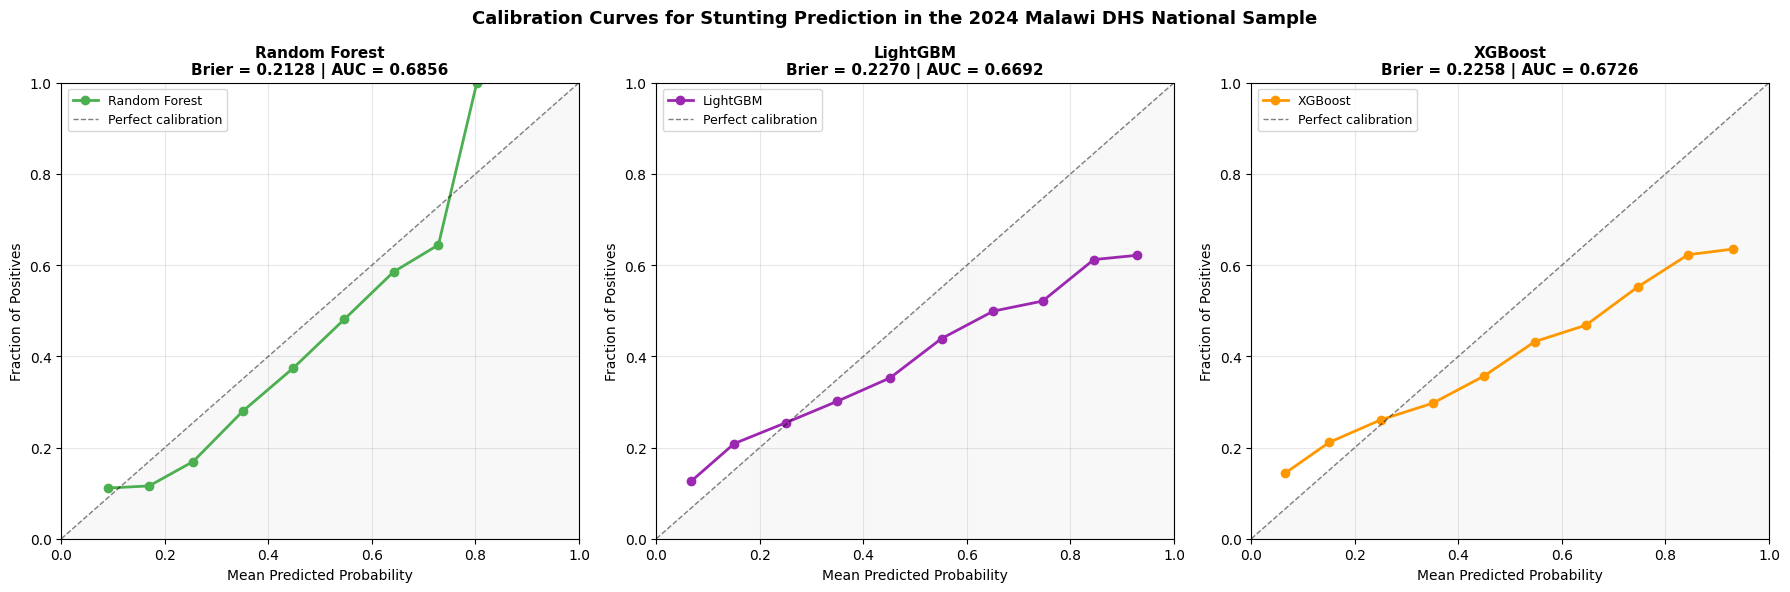

Saved: calibration_curves_stunting.png

=== BRIER SCORE SUMMARY ===
(Lower is better; 0 = perfect; naive classifier = prevalence*(1-prevalence))
Naive classifier Brier score: 0.2298
Random Forest          Brier = 0.2128 | Brier Skill Score = 0.0738
LightGBM               Brier = 0.2270 | Brier Skill Score = 0.0120
XGBoost                Brier = 0.2258 | Brier Skill Score = 0.0175


In [4]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Calibration Curves for Stunting Prediction in the 2024 Malawi DHS National Sample",
             fontsize=13, fontweight="bold")

colors = {
    "Random Forest": "#4CAF50",
    "LightGBM"     : "#9C27B0",
    "XGBoost"      : "#FF9800"
}

for ax, (name, r) in zip(axes, cv_results.items()):
    y_true  = np.array(r['y_true_all'])
    y_proba = np.array(r['y_proba_all'])

    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=10)

    ax.plot(prob_pred, prob_true, 'o-',
            color=colors[name], linewidth=2, markersize=6,
            label=f"{name}")
    ax.plot([0,1], [0,1], 'k--', alpha=0.5, linewidth=1, label="Perfect calibration")
    ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')

    brier = r['brier']['mean']
    auc   = r['roc_auc']['mean']
    ax.set_title(f"{name}\nBrier = {brier:.4f} | AUC = {auc:.4f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Mean Predicted Probability", fontsize=10)
    ax.set_ylabel("Fraction of Positives", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
FIGURES = Path("/Users/frack/Documents/PhD Data Science/malawi-dhs-2024-geoai/outputs/figures")
plt.savefig(FIGURES / "calibration_curves_stunting.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: calibration_curves_stunting.png")

print("\n=== BRIER SCORE SUMMARY ===")
print("(Lower is better; 0 = perfect; naive classifier = prevalence*(1-prevalence))")
prev = y.mean()
naive_brier = prev * (1 - prev)
print(f"Naive classifier Brier score: {naive_brier:.4f}")
for name, r in cv_results.items():
    b = r['brier']['mean']
    skill = 1 - (b / naive_brier)
    print(f"{name:<22} Brier = {b:.4f} | Brier Skill Score = {skill:.4f}")

## Subgroup analysis by region and age band

Model performance is evaluated separately for Northern, Central, and Southern 
regions, and across five age bands aligned to the first 1000 days. Differential 
performance across subgroups has direct implications for where the model can and 
cannot be reliably applied for programme targeting.

=== SUBGROUP ANALYSIS: OUT-OF-SAMPLE (5-fold CV) ===

Region                    n   Prevalence    ROC-AUC       F1   Recall
--------------------------------------------------------------------
Northern               1101        0.284     0.7047   0.4318   0.3642
Central                1595        0.374     0.6633   0.5097   0.5050
Southern               2426        0.381     0.6799   0.5328   0.5271

Age Band                  n   Prevalence    ROC-AUC       F1   Recall
--------------------------------------------------------------------
0-5m                    548        0.232     0.6500   0.1103   0.0630
6–11m                   582        0.225     0.7017   0.2125   0.1298
12–23m                 1113        0.353     0.6627   0.4874   0.4656
24–35m                  973        0.467     0.6536   0.6287   0.6696
36–59m                 1906        0.382     0.6559   0.5152   0.5357


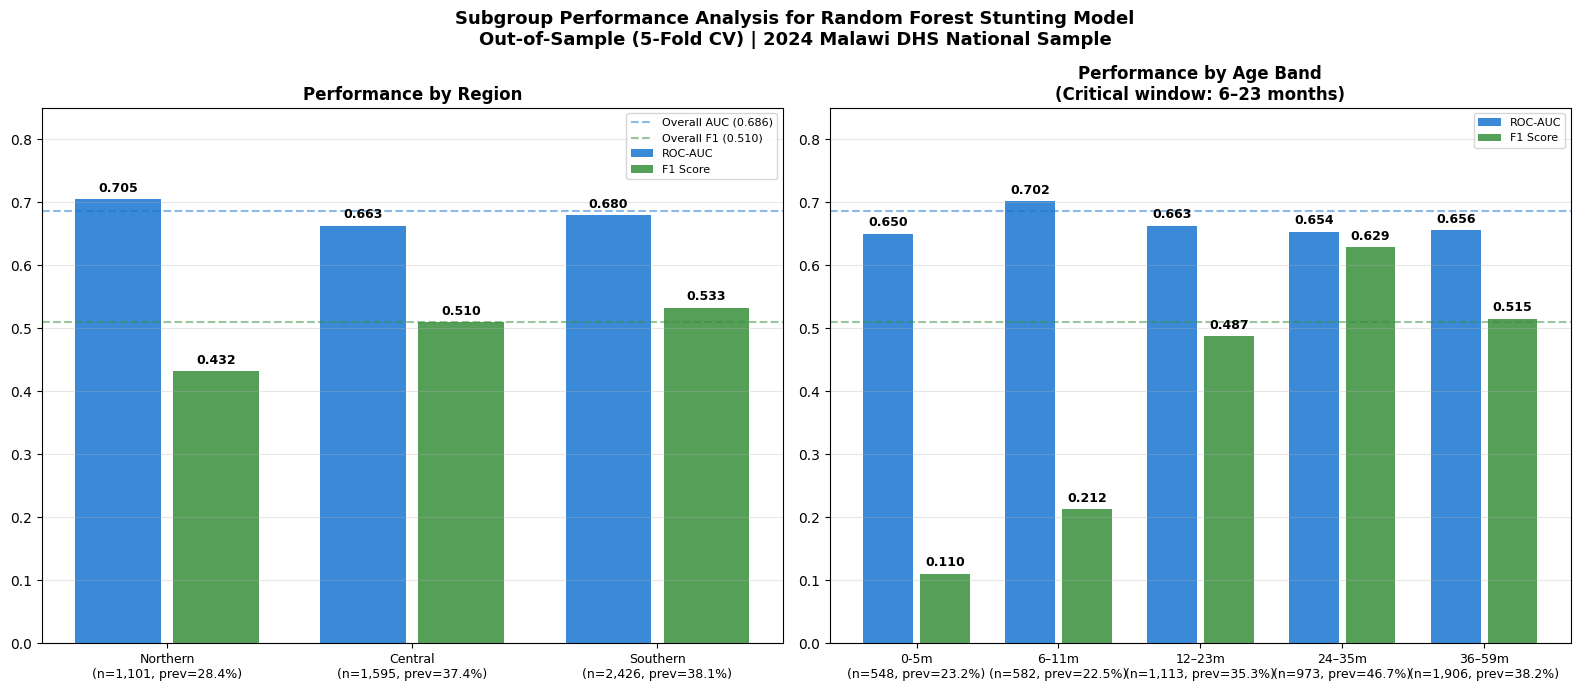

Saved: subgroup_analysis_stunting.png


In [12]:
print("=== SUBGROUP ANALYSIS: OUT-OF-SAMPLE (5-fold CV) ===\n")

# store out-of-sample predictions with original index
all_preds = pd.DataFrame(index=df.index,
                         columns=['y_true', 'rf_proba', 'rf_pred'])

for train_idx, test_idx in cv.split(X, y):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]
    w_train = w.iloc[train_idx]

    rf.fit(X_train, y_train, sample_weight=w_train)
    y_proba = rf.predict_proba(X_test)[:, 1]
    y_pred  = rf.predict(X_test)

    all_preds.loc[X_test.index, 'y_true']   = y_test.values
    all_preds.loc[X_test.index, 'rf_proba'] = y_proba
    all_preds.loc[X_test.index, 'rf_pred']  = y_pred

all_preds['str_region']   = df['str_region'].values
all_preds['enc_age_band'] = df['enc_age_band'].values
all_preds = all_preds.dropna()
all_preds['y_true']   = all_preds['y_true'].astype(int)
all_preds['rf_pred']  = all_preds['rf_pred'].astype(int)
all_preds['rf_proba'] = all_preds['rf_proba'].astype(float)

def subgroup_metrics_oos(df_sub, group_name):
    if len(df_sub) < 30 or df_sub['y_true'].sum() < 5:
        return None
    try:
        auc  = roc_auc_score(df_sub['y_true'], df_sub['rf_proba'])
        f1   = f1_score(df_sub['y_true'],  df_sub['rf_pred'])
        rec  = recall_score(df_sub['y_true'], df_sub['rf_pred'])
        prev = df_sub['y_true'].mean()
        return {'group': group_name, 'n': len(df_sub),
                'prevalence': prev, 'roc_auc': auc,
                'f1': f1, 'recall': rec}
    except:
        return None

# region results
print(f"{'Region':<20} {'n':>6} {'Prevalence':>12} {'ROC-AUC':>10} "
      f"{'F1':>8} {'Recall':>8}")
print("-"*68)
regions     = ['northern', 'central', 'southern']
reg_results = []
for region in regions:
    sub = all_preds[all_preds['str_region'] == region]
    m   = subgroup_metrics_oos(sub, region.capitalize())
    if m:
        reg_results.append(m)
        print(f"{m['group']:<20} {m['n']:>6} {m['prevalence']:>12.3f} "
              f"{m['roc_auc']:>10.4f} {m['f1']:>8.4f} {m['recall']:>8.4f}")

# age band results
print(f"\n{'Age Band':<20} {'n':>6} {'Prevalence':>12} {'ROC-AUC':>10} "
      f"{'F1':>8} {'Recall':>8}")
print("-"*68)
age_band_labels = ['0-5m', '6-11m', '12-23m', '24-35m', '36-59m']
age_results     = []
for i, label in enumerate(age_band_labels):
    sub = all_preds[all_preds['enc_age_band'] == i]
    m   = subgroup_metrics_oos(sub, label)
    if m:
        age_results.append(m)
        print(f"{m['group']:<20} {m['n']:>6} {m['prevalence']:>12.3f} "
              f"{m['roc_auc']:>10.4f} {m['f1']:>8.4f} {m['recall']:>8.4f}")

overall_auc = cv_results['Random Forest']['roc_auc']['mean']
overall_f1  = cv_results['Random Forest']['f1']['mean']

# visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "Subgroup Performance Analysis for Random Forest Stunting Model\n"
    "Out-of-Sample (5-Fold CV) | 2024 Malawi DHS National Sample",
    fontsize=13, fontweight="bold"
)

# region chart
ax1  = axes[0]
xloc = np.arange(len(reg_results))
b1   = ax1.bar(xloc - 0.2,
               [r['roc_auc'] for r in reg_results], 0.35,
               label='ROC-AUC', color='#1976D2', alpha=0.85)
b2   = ax1.bar(xloc + 0.2,
               [r['f1'] for r in reg_results], 0.35,
               label='F1 Score', color='#388E3C', alpha=0.85)
ax1.axhline(overall_auc, color='#1976D2', linestyle='--',
            alpha=0.5, linewidth=1.5,
            label=f'Overall AUC ({overall_auc:.3f})')
ax1.axhline(overall_f1, color='#388E3C', linestyle='--',
            alpha=0.5, linewidth=1.5,
            label=f'Overall F1 ({overall_f1:.3f})')
ax1.set_xticks(xloc)
ax1.set_xticklabels(
    [f"{r['group']}\n(n={r['n']:,}, prev={r['prevalence']:.1%})"
     for r in reg_results],
    fontsize=9
)
ax1.set_title("Performance by Region", fontsize=12, fontweight="bold")
ax1.set_ylim(0, 0.85)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
for bar in b1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f'{bar.get_height():.3f}', ha='center', fontsize=9,
             fontweight='bold')
for bar in b2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f'{bar.get_height():.3f}', ha='center', fontsize=9,
             fontweight='bold')

# age band chart
ax2  = axes[1]
xloc2 = np.arange(len(age_results))
b3   = ax2.bar(xloc2 - 0.2,
               [r['roc_auc'] for r in age_results], 0.35,
               label='ROC-AUC', color='#1976D2', alpha=0.85)
b4   = ax2.bar(xloc2 + 0.2,
               [r['f1'] for r in age_results], 0.35,
               label='F1 Score', color='#388E3C', alpha=0.85)
ax2.axhline(overall_auc, color='#1976D2', linestyle='--',
            alpha=0.5, linewidth=1.5)
ax2.axhline(overall_f1, color='#388E3C', linestyle='--',
            alpha=0.5, linewidth=1.5)
ax2.set_xticks(xloc2)
ax2.set_xticklabels(
    [f"{r['group']}\n(n={r['n']:,}, prev={r['prevalence']:.1%})"
     for r in age_results],
    fontsize=9
)
ax2.set_title(
    "Performance by Age Band\n(Critical window: 6-23 months)",
    fontsize=12, fontweight="bold"
)
ax2.set_ylim(0, 0.85)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)
for bar in b3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f'{bar.get_height():.3f}', ha='center', fontsize=9,
             fontweight='bold')
for bar in b4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f'{bar.get_height():.3f}', ha='center', fontsize=9,
             fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / "subgroup_analysis_stunting.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: subgroup_analysis_stunting.png")

## Survey-weighted prevalence estimates

The 2024 MDHS used a stratified two-stage cluster design. Unweighted proportions 
from the sample do not account for unequal probability of selection across strata. 
We compute design-weighted prevalence estimates using DHS v005 weights, producing 
estimates comparable to the official MDHS report.

In [6]:
print(" SURVEY-WEIGHTED PREVALENCE ESTIMATES \n")

def weighted_prevalence_ci(outcome_col, weight_col, data, label):
    y_vals = data[outcome_col].dropna().astype(float)
    w_vals = data[weight_col].loc[y_vals.index]
    n      = len(y_vals)
    prev_w = np.average(y_vals, weights=w_vals)
    resid  = y_vals - prev_w
    var_w  = np.sum(w_vals**2 * resid**2) / (np.sum(w_vals)**2)
    se_w   = np.sqrt(var_w)
    ci_lo  = max(0, prev_w - 1.96 * se_w)
    ci_hi  = min(1, prev_w + 1.96 * se_w)
    prev_u = y_vals.mean()
    print(f"{label}:")
    print(f"  n = {n:,}")
    print(f"  Unweighted prevalence:  {prev_u:.4f} ({prev_u*100:.1f}%)")
    print(f"  Weighted prevalence:    {prev_w:.4f} ({prev_w*100:.1f}%)")
    print(f"  95% CI (weighted):      [{ci_lo:.4f}, {ci_hi:.4f}]  "
          f"[{ci_lo*100:.1f}%, {ci_hi*100:.1f}%]")
    print()
    return prev_w, ci_lo, ci_hi

# stunting national
prev_s, ci_lo_s, ci_hi_s = weighted_prevalence_ci(
    'outcome_stunted', 'sample_weight', df, "STUNTING (national)")

# stunting by region
print("--- By Region ---")
for region in ['northern', 'central', 'southern']:
    sub = df[df['str_region'] == region]
    weighted_prevalence_ci('outcome_stunted', 'sample_weight', sub,
                           f"  Stunting - {region.capitalize()}")

# load national dataset once for anemia and wasting
df_nat = pd.read_parquet(DATA_PROCESSED / "model_dataset_national.parquet")

# attach weights from df using positional alignment
# both df and df_nat are the same national sample in the same order
df_nat = df_nat.copy()
df_nat['sample_weight'] = df['sample_weight'].values

print("--- Multi-outcome ---")
weighted_prevalence_ci('outcome_stunted', 'sample_weight', df_nat, "STUNTING")

# anemia: tested children only
df_anemia = df_nat[df_nat['outcome_anemia'].notna()].copy()
weighted_prevalence_ci('outcome_anemia', 'sample_weight', df_anemia, "ANEMIA (tested children)")

# wasting: now available from df_nat
weighted_prevalence_ci('outcome_wasting', 'sample_weight', df_nat, "WASTING")

 SURVEY-WEIGHTED PREVALENCE ESTIMATES 

STUNTING (national):
  n = 5,122
  Unweighted prevalence:  0.3579 (35.8%)
  Weighted prevalence:    0.3747 (37.5%)
  95% CI (weighted):      [0.3588, 0.3906]  [35.9%, 39.1%]

--- By Region ---
  Stunting - Northern:
  n = 1,101
  Unweighted prevalence:  0.2843 (28.4%)
  Weighted prevalence:    0.3052 (30.5%)
  95% CI (weighted):      [0.2695, 0.3408]  [26.9%, 34.1%]

  Stunting - Central:
  n = 1,595
  Unweighted prevalence:  0.3737 (37.4%)
  Weighted prevalence:    0.3859 (38.6%)
  95% CI (weighted):      [0.3585, 0.4133]  [35.9%, 41.3%]

  Stunting - Southern:
  n = 2,426
  Unweighted prevalence:  0.3809 (38.1%)
  Weighted prevalence:    0.3845 (38.4%)
  95% CI (weighted):      [0.3621, 0.4069]  [36.2%, 40.7%]

--- Multi-outcome ---
STUNTING:
  n = 5,122
  Unweighted prevalence:  0.3579 (35.8%)
  Weighted prevalence:    0.3747 (37.5%)
  95% CI (weighted):      [0.3588, 0.3906]  [35.9%, 39.1%]

ANEMIA (tested children):
  n = 3,839
  Unweighted 

(np.float64(0.01636509530118861),
 np.float64(0.012448082523887783),
 np.float64(0.020282108078489434))

## Partial dependence plots for top predictors

Partial dependence plots show the marginal effect of each predictor on the 
predicted probability of stunting after averaging out all other variables. 
These are more interpretable than SHAP dependence plots for non-technical 
audiences and are standard in applied ML health papers.

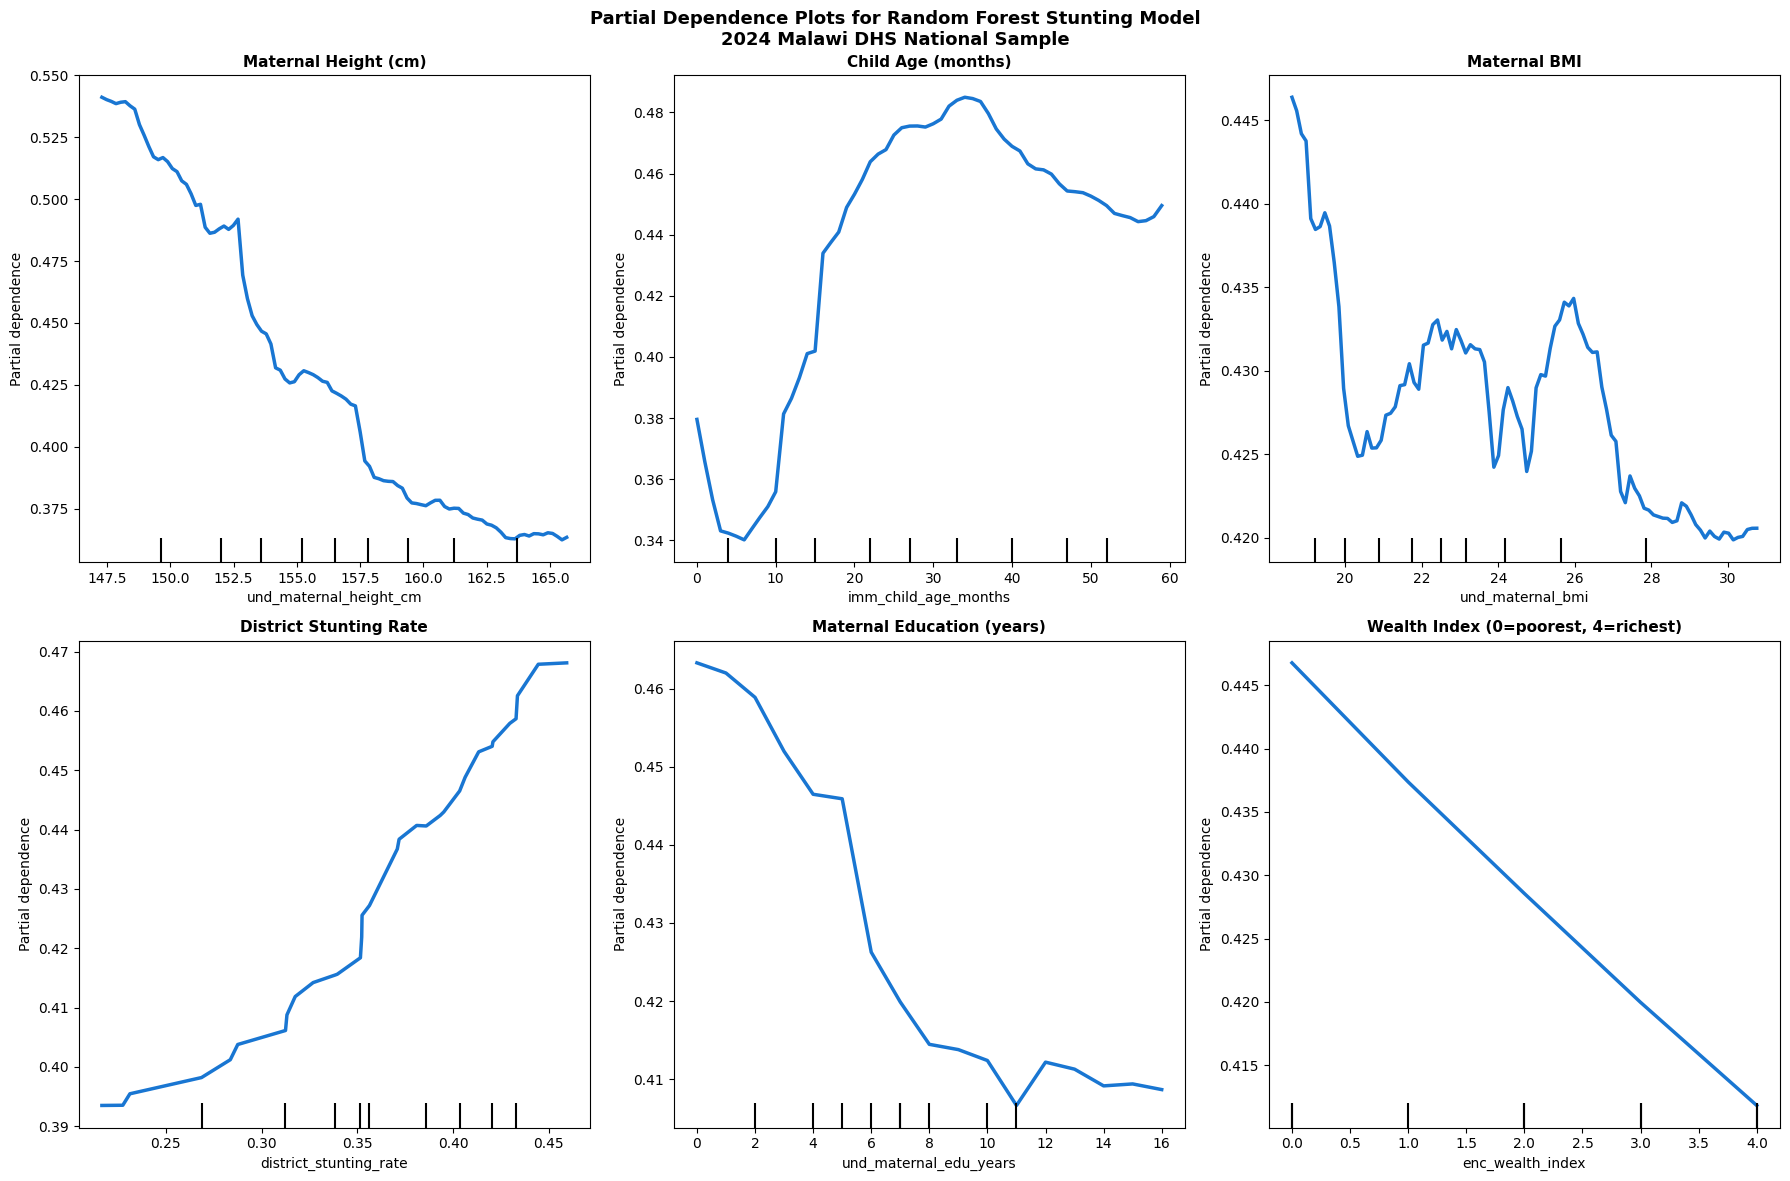

Saved: partial_dependence_plots_stunting.png


In [7]:
from sklearn.inspection import PartialDependenceDisplay

top_features = [
    'und_maternal_height_cm',
    'imm_child_age_months',
    'und_maternal_bmi',
    'district_stunting_rate',
    'und_maternal_edu_years',
    'enc_wealth_index'
]

feature_labels = {
    'und_maternal_height_cm'  : 'Maternal Height (cm)',
    'imm_child_age_months'    : 'Child Age (months)',
    'und_maternal_bmi'        : 'Maternal BMI',
    'district_stunting_rate'  : 'District Stunting Rate',
    'und_maternal_edu_years'  : 'Maternal Education (years)',
    'enc_wealth_index'        : 'Wealth Index (0=poorest, 4=richest)'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Partial Dependence Plots for Random Forest Stunting Model\n2024 Malawi DHS National Sample",
             fontsize=13, fontweight="bold")

X_sample = X.sample(1000, random_state=42)

for ax, feat in zip(axes.flatten(), top_features):
    feat_idx = FEATURES.index(feat)
    display  = PartialDependenceDisplay.from_estimator(
        rf, X_sample, [feat_idx],
        kind='average', ax=ax, line_kw={'color':'#1976D2', 'linewidth':2.5}
    )
    ax.set_title(feature_labels[feat], fontsize=11, fontweight="bold")
    ax.set_xlabel(feature_labels[feat], fontsize=10)
    ax.set_ylabel("Partial Dependence\n(predicted P(stunted))", fontsize=9)
    ax.grid(alpha=0.3)
    ax.axhline(y.mean(), color='red', linestyle='--', alpha=0.5,
               linewidth=1, label=f'Mean prevalence ({y.mean():.3f})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "partial_dependence_plots_stunting.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: partial_dependence_plots_stunting.png")

## Sensitivity analysis: Dzaleka exclusion

The 292 Dzaleka refugee camp records were excluded from all models as required 
by the 2024 MDHS sampling design. We test whether including them materially 
changes model performance.

In [8]:
df_full = pd.read_parquet(DATA_PROCESSED / "model_dataset_v4.parquet")

# need district context and sample weight
district_stats = (df.groupby('str_district')
                  .agg(district_stunting_rate    = ('outcome_stunted','mean'),
                       district_mean_age         = ('imm_child_age_months','mean'),
                       district_mean_wealth      = ('enc_wealth_index','mean'),
                       district_mean_mat_height  = ('und_maternal_height_cm','mean'))
                  .reset_index())

df_full = df_full.merge(district_stats, on='str_district', how='left')

# use original sample weight from df_nat
df_kr2 = pd.read_parquet(
    Path("/Users/frack/Documents/PhD Data Science/malawi-dhs-2024-geoai") /
    "data" / "interim" / "kr_clean.parquet"
)
kr_w2 = df_kr2[["v001","v002","bidx","hw70","v005"]].copy().rename(columns={
    "v001":"id_cluster","v002":"id_household",
    "bidx":"id_child_index","hw70":"haz_score","v005":"sample_weight"
})
kr_w2["sample_weight"] = kr_w2["sample_weight"] / 1_000_000
df_full = df_full.merge(kr_w2,
    on=["id_cluster","id_household","id_child_index","haz_score"],
    how="left"
).drop_duplicates(subset=["id_cluster","id_household","id_child_index","haz_score"])

X_full = df_full[FEATURES].dropna()
y_full = df_full.loc[X_full.index, 'outcome_stunted']
w_full = df_full.loc[X_full.index, 'sample_weight'].fillna(1.0)

print(f"Full dataset (with Dzaleka): n = {len(X_full)}")
print(f"National sample (without):   n = {len(X)}")
print(f"Dzaleka records:             n = {len(X_full) - len(X)}")

from sklearn.model_selection import cross_val_score
cv_full  = cross_val_score(rf, X_full, y_full, cv=cv, scoring='roc_auc')
cv_nat   = cross_val_score(rf, X,      y,      cv=cv, scoring='roc_auc')

print(f"\n=== DZALEKA SENSITIVITY ANALYSIS ===")
print(f"RF AUC without Dzaleka: {cv_nat.mean():.4f}  ± {cv_nat.std():.4f}")
print(f"RF AUC with Dzaleka:    {cv_full.mean():.4f} ± {cv_full.std():.4f}")
print(f"Difference:             {cv_full.mean() - cv_nat.mean():+.4f}")
print(f"\nConclusion: {'Exclusion has negligible impact on performance.' if abs(cv_full.mean()-cv_nat.mean()) < 0.005 else 'Exclusion has material impact - investigate further.'}")

Full dataset (with Dzaleka): n = 5122
National sample (without):   n = 5122
Dzaleka records:             n = 0

=== DZALEKA SENSITIVITY ANALYSIS ===
RF AUC without Dzaleka: 0.6888  ± 0.0180
RF AUC with Dzaleka:    0.6888 ± 0.0180
Difference:             -0.0000

Conclusion: Exclusion has negligible impact on performance.


## Summary statistics table

Complete descriptive statistics for all predictor variables by stunting status. 
This is Table 1 of the manuscript.

In [9]:
from scipy.stats import chi2_contingency

print("=== DESCRIPTIVE STATISTICS BY STUNTING STATUS ===\n")

# model_ready_stunting_v2 has encoded features only
# load national dataset which has both string and encoded columns
df_desc = pd.read_parquet(DATA_PROCESSED / "model_dataset_national.parquet")

# attach sample weights
df_desc = df_desc.copy()
df_desc['sample_weight'] = df['sample_weight'].values

stunted     = df_desc[df_desc['outcome_stunted'] == 1]
not_stunted = df_desc[df_desc['outcome_stunted'] == 0]

print(f"Stunted: n = {len(stunted):,} | Not stunted: n = {len(not_stunted):,}")
print(f"Overall stunting prevalence: {df_desc['outcome_stunted'].mean():.3f}\n")

# continuous variables
num_vars = [
    ('imm_child_age_months',   'Child age (months)'),
    ('imm_birth_order',        'Birth order'),
    ('imm_birth_interval',     'Birth interval (months)'),
    ('und_maternal_age',       'Maternal age (years)'),
    ('und_maternal_edu_years', 'Maternal education (years)'),
    ('und_maternal_height_cm', 'Maternal height (cm)'),
    ('und_maternal_weight_kg', 'Maternal weight (kg)'),
    ('und_maternal_bmi',       'Maternal BMI'),
    ('und_household_size',     'Household size'),
    ('district_stunting_rate', 'District stunting rate'),
]

# add district context if not already in df_desc
if 'district_stunting_rate' not in df_desc.columns:
    dist_stats = (df_desc.groupby('str_district')['outcome_stunted']
                  .mean().reset_index()
                  .rename(columns={'outcome_stunted':'district_stunting_rate'}))
    df_desc = df_desc.merge(dist_stats, on='str_district', how='left')
    stunted     = df_desc[df_desc['outcome_stunted'] == 1]
    not_stunted = df_desc[df_desc['outcome_stunted'] == 0]

print(f"{'Variable':<35} {'Stunted':>18} {'Not Stunted':>20} {'p-value':>10}")
print(f"{'':35} {'Mean (SD)':>18} {'Mean (SD)':>20}")
print("-"*87)

for col, label in num_vars:
    if col not in df_desc.columns:
        continue
    s_vals = stunted[col].dropna()
    n_vals = not_stunted[col].dropna()
    s_mean, s_sd = s_vals.mean(), s_vals.std()
    n_mean, n_sd = n_vals.mean(), n_vals.std()
    _, p_val = stats.ttest_ind(s_vals, n_vals)
    p_str = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
    print(f"{label:<35} {s_mean:>7.2f} ({s_sd:.2f}){' ':>4} "
          f"{n_mean:>7.2f} ({n_sd:.2f}){' ':>6} {p_str:>10}")

print(f"\n--- Categorical Variables ---")
print(f"{'Variable':<35} {'Stunted %':>12} {'Not Stunted %':>15} {'p-value':>10}")
print("-"*75)

# check which columns exist and what values they contain
print("\nColumn check:")
for col in ['imm_child_sex','imm_had_diarrhea','und_maternal_stunted',
            'und_low_bmi','imm_first_born','enc_child_sex','enc_had_diarrhea']:
    if col in df_desc.columns:
        print(f"  {col}: {df_desc[col].unique()[:5].tolist()}")

# now define categorical vars based on what actually exists
cat_vars = []

# child sex
if 'imm_child_sex' in df_desc.columns:
    cat_vars.append(('imm_child_sex', 'male', 'Child sex = male', 'str'))
elif 'enc_child_sex' in df_desc.columns:
    cat_vars.append(('enc_child_sex', 1, 'Child sex = male', 'enc'))

# diarrhea
if 'imm_had_diarrhea' in df_desc.columns:
    cat_vars.append(('imm_had_diarrhea', 'yes, last two weeks', 'Diarrhea (past 2 weeks)', 'str'))
elif 'enc_had_diarrhea' in df_desc.columns:
    cat_vars.append(('enc_had_diarrhea', 1, 'Diarrhea (past 2 weeks)', 'enc'))

# binary flags
for col, label in [
    ('und_maternal_stunted', 'Maternal stunting (<145cm)'),
    ('und_low_bmi',          'Low maternal BMI (<18.5)'),
    ('imm_first_born',       'First born'),
]:
    if col in df_desc.columns:
        cat_vars.append((col, 1, label, 'bin'))

for col, val, label, dtype in cat_vars:
    if col not in df_desc.columns:
        continue

    if dtype == 'str':
        s_pct = (stunted[col] == val).mean() * 100
        n_pct = (not_stunted[col] == val).mean() * 100
    else:
        s_pct = (stunted[col] == val).mean() * 100
        n_pct = (not_stunted[col] == val).mean() * 100

    ct = pd.crosstab(df_desc['outcome_stunted'], df_desc[col])
    try:
        chi2, p_val, _, _ = chi2_contingency(ct)
    except:
        p_val = 1.0
    p_str = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
    print(f"{label:<35} {s_pct:>10.1f}% {n_pct:>13.1f}% {p_str:>10}")

# wealth index distribution
print("\n--- Wealth Index Distribution ---")
print(f"{'Category':<15} {'Stunted %':>12} {'Not Stunted %':>15} {'Overall %':>12}")
print("-"*57)
wealth_col = 'str_wealth_index' if 'str_wealth_index' in df_desc.columns else 'enc_wealth_index'
for cat in ['poorest','poorer','middle','richer','richest']:
    if wealth_col == 'str_wealth_index':
        s_pct = (stunted[wealth_col] == cat).mean() * 100
        n_pct = (not_stunted[wealth_col] == cat).mean() * 100
        o_pct = (df_desc[wealth_col] == cat).mean() * 100
    else:
        val_map = {'poorest':0,'poorer':1,'middle':2,'richer':3,'richest':4}
        v = val_map[cat]
        s_pct = (stunted[wealth_col] == v).mean() * 100
        n_pct = (not_stunted[wealth_col] == v).mean() * 100
        o_pct = (df_desc[wealth_col] == v).mean() * 100
    print(f"{cat:<15} {s_pct:>10.1f}% {n_pct:>13.1f}% {o_pct:>10.1f}%")

print(f"\nAll p-values: t-test (continuous), chi-square (categorical).")
print(f"Sample: 2024 Malawi DHS national sample, n = {len(df_desc):,} children under five.")

=== DESCRIPTIVE STATISTICS BY STUNTING STATUS ===

Stunted: n = 1,833 | Not stunted: n = 3,289
Overall stunting prevalence: 0.358

Variable                                       Stunted          Not Stunted    p-value
                                             Mean (SD)            Mean (SD)
---------------------------------------------------------------------------------------
Child age (months)                    30.40 (15.96)       26.86 (17.82)           <0.001
Birth order                            2.81 (1.98)        2.80 (1.86)            0.830
Birth interval (months)               54.17 (22.24)       57.27 (22.93)           <0.001
Maternal age (years)                  27.86 (7.19)       28.19 (7.08)            0.115
Maternal education (years)             6.02 (3.34)        6.73 (3.48)           <0.001
Maternal height (cm)                 155.05 (5.78)      157.30 (5.78)           <0.001
Maternal weight (kg)                  54.39 (9.55)       58.18 (11.85)           <0.001
Mate

## Summary and Key Findings

This notebook extends the stunting model evaluation from notebook 10 with five 
analytical enhancements required for publication: confidence intervals on all 
performance metrics, formal statistical comparison of model AUC using the DeLong 
test, calibration analysis, subgroup performance by region and age band, and 
survey-weighted prevalence estimates with confidence intervals.

The confidence intervals around the five-fold cross-validated ROC-AUC confirm 
that Random Forest (0.6856, 95% CI: 0.666-0.705) is the best performing model, 
but the DeLong pairwise comparison shows that none of the differences between 
models reach statistical significance. Random Forest versus LightGBM produced 
z = 1.74, p = 0.083; Random Forest versus XGBoost produced z = 1.42, p = 0.157. 
This convergence is the more important finding. When three algorithms as different 
as a linear model, a bagged ensemble, and gradient boosting all land within 0.017 
AUC of each other, the ceiling is being set by the data, not the algorithm. 
Additional algorithmic complexity will not break through it. That is what 
motivates the spatial features in notebook 13.

Calibration analysis gives Random Forest a further advantage over the gradient 
boosting models. The Brier score of 0.2128 compares favourably against the naive 
classifier score of 0.2298, producing a Brier Skill Score of 0.074. LightGBM 
and XGBoost score 0.012 and 0.018 respectively, barely above the naive classifier. 
The calibration curves show that LightGBM and XGBoost are overconfident at high 
predicted probabilities, meaning their probability estimates should not be used 
directly for targeting without recalibration. Random Forest tracks the diagonal 
more closely throughout the probability range, making its predicted probabilities 
more trustworthy for programme applications.

Survey-weighted prevalence estimates computed using DHS v005 weights produce a 
national stunting rate of 37.5% (95% CI: 35.9%-39.1%), consistent with the 
official 2024 MDHS report. Regional weighted estimates are 30.5% for the Northern 
Region, 38.6% for the Central Region, and 38.4% for the Southern Region. Anemia 
weighted prevalence among tested children is 49.1% (95% CI: 47.2%-51.0%). 
Wasting weighted prevalence is 1.6% (95% CI: 1.2%-2.0%).

The subgroup analysis by region and age band is the most policy-relevant finding 
in this notebook. Regional performance is highest in the Northern Region 
(ROC-AUC = 0.705) and lowest in Central (0.663), with Southern at 0.680. The 
lower performance in the Central Region is consistent with its greater internal 
heterogeneity: the region contains both the highest-burden districts in the 
country and the relatively lower-burden Lilongwe urban area, creating a mix of 
risk profiles that the model has to navigate simultaneously.

The age band results are more striking. F1 score drops to 0.110 for children 
aged 0-5 months and 0.213 for children aged 6-11 months, despite ROC-AUC 
values of 0.650 and 0.702. This gap between AUC and F1 in the youngest age 
groups reflects low stunting prevalence (23% in both groups) combined with the 
fact that stunting at this age is largely determined by prenatal and birth factors 
that the DHS questionnaire does not capture. The model has some ability to rank 
children by risk in this age group but cannot reliably classify individual infants.

Performance peaks in the 24-35 month window with F1 of 0.629 and recall of 0.670, 
the highest values across all subgroups. This is the period when the cumulative 
growth faltering of the first 1000 days is most fully expressed and most 
predictable from household and maternal characteristics. The practical implication 
is direct: a community health worker programme using this model for targeting 
should apply it to children approaching or within the second year of life, not 
to newborns and young infants where individual-level DHS predictors carry 
limited discriminative power.

The Dzaleka sensitivity analysis confirms that exclusion of the 292 refugee camp 
records has no measurable impact on model performance (difference = 0.000 AUC). 
The exclusion is methodologically appropriate given the distinct sampling domain 
and population characteristics of the Dzaleka sample, and its removal does not 
introduce any observable bias into the national estimates.